# Predicting Lithium-Polymer Battery Capacity Degradation Using Machine Learning

Objective: To develop a machine learning model that predicts lithium-polymer battery capacity degradation across charge–discharge cycles, enabling better understanding of lithium-based battery aging behavior and performance.

For this project, I have used a publicly available dataset from Kaggle based on experimental testing of five Lithium-Polymer (LiPo) batteries

[LiPo Battery Dataset](https://www.kaggle.com/datasets/jamesusevitch/lipo-battery-dataset/data)

Lithium-Polymer (LiPo) batteries are widely used in electric vehicles, renewable energy storage systems, drones, and portable electronics due to their high energy density and lightweight design. However, batteries naturally degrade over time as they undergo repeated charging and discharging cycles.

This degradation reduces:
 - Capacity (the total amount of energy a battery can store),
 - Voltage stability, and
 - Overall performance and safety.

To study battery health, researchers evaluate performance under Standard and
Stress conditions

By measuring how voltage changes as charge is extracted, we gain insights into the battery’s internal resistance and chemical aging. A healthy battery maintains voltage longer as it discharges, whereas a degraded or stressed battery experiences faster voltage drop.

Predicting capacity degradation is critical for:
- Increasing battery lifespan and safety,
- Improving lithium material and manufacturing processes,
- Reducing waste and supporting sustainability goals,
- Planning predictive maintenance and lifecycle costing.

This project applies machine learning to real experimental battery data to model capacity decline and identify the most influential indicators of battery aging.

## Loading the dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jamesusevitch/lipo-battery-dataset")

print("Path to dataset files:", path)

100%|██████████| 27.0M/27.0M [00:00<00:00, 125MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jamesusevitch/lipo-battery-dataset/versions/1


In [ ]:
import os
import shutil

local_dir = "./"
os.makedirs(local_dir, exist_ok=True)

# Copy all CSV files from kagglehub download folder to local working directory
for file in os.listdir(path):
    if file.endswith(".csv"):
        shutil.copy(os.path.join(path, file), local_dir)

print("Files copied to current folder:", os.listdir(local_dir))

Files copied to current folder: ['.config', 'cycle_voltage_extracted_charge_std.csv', 'cycle_vs_capacity.csv', 'cycle_voltage_extracted_charge_stress.csv', 'sample_data']


In [ ]:
import pandas as pd

capacity_df = pd.read_csv("./cycle_vs_capacity.csv")
std_df = pd.read_csv("./cycle_voltage_extracted_charge_std.csv")
stress_df = pd.read_csv("./cycle_voltage_extracted_charge_stress.csv")

## Task 1: Data Exploration

In [ ]:
print("capacity_df:", capacity_df.shape)
print("std_df:", std_df.shape)
print("stress_df:", stress_df.shape)

capacity_df: (57, 3)
std_df: (185351, 4)
stress_df: (1802381, 4)


In [ ]:
print("cycle_vs_capacity.csv")
display(capacity_df.head())
capacity_df.info()

cycle_vs_capacity.csv


,battery_id,cycle_number,capacity_Ah
0,1,0,1.026553
1,1,45,0.994610
2,1,90,0.956809
3,1,116,0.940173
4,1,135,0.922093


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   battery_id    57 non-null     int64  
 1   cycle_number  57 non-null     int64  
 2   capacity_Ah   57 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.5 KB


In [ ]:
print("\ncycle_voltage_extracted_charge_std.csv")
display(std_df.head())
std_df.info()


cycle_voltage_extracted_charge_std.csv


,battery_id,cycle_number,extracted_charge_Ah,voltage_V
0,1,0,0.000000,3.989748
1,1,0,0.000278,3.982912
2,1,0,0.000556,3.980002
3,1,0,0.000833,3.977724
4,1,0,0.001111,3.975733


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185351 entries, 0 to 185350
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   battery_id           185351 non-null  int64  
 1   cycle_number         185351 non-null  int64  
 2   extracted_charge_Ah  185351 non-null  float64
 3   voltage_V            185351 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 5.7 MB


In [ ]:
print("\ncycle_voltage_extracted_charge_stress.csv")
display(stress_df.head())
stress_df.info()


cycle_voltage_extracted_charge_stress.csv


,battery_id,cycle_number,extracted_charge_Ah,voltage_V
0,1,0,0.000000,3.822322
1,1,0,0.000833,3.795257
2,1,0,0.001667,3.781915
3,1,0,0.002500,3.771808
4,1,0,0.003333,3.763345


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1802381 entries, 0 to 1802380
Data columns (total 4 columns):
 #   Column               Dtype  
---  ------               -----  
 0   battery_id           int64  
 1   cycle_number         int64  
 2   extracted_charge_Ah  float64
 3   voltage_V            float64
dtypes: float64(2), int64(2)
memory usage: 55.0 MB


In [ ]:
print("Missing Values Summary:\n")
print("capacity_df:\n", capacity_df.isnull().sum())
print("\nstd_df:\n", std_df.isnull().sum())
print("\nstress_df:\n", stress_df.isnull().sum())

Missing Values Summary:

capacity_df:
 battery_id      0
cycle_number    0
capacity_Ah     0
dtype: int64

std_df:
 battery_id             0
cycle_number           0
extracted_charge_Ah    0
voltage_V              0
dtype: int64

stress_df:
 battery_id             0
cycle_number           0
extracted_charge_Ah    0
voltage_V              0
dtype: int64


There are no null values in the given dataset

In [ ]:
print("Capacity Stats")
display(capacity_df.describe())

Capacity Stats


,battery_id,cycle_number,capacity_Ah
count,57.000000,57.000000,57.000000
mean,3.052632,189.736842,0.914231
std,1.368276,136.799714,0.095533
min,1.000000,0.000000,0.646048
25%,2.000000,90.000000,0.871018
50%,3.000000,180.000000,0.940982
75%,4.000000,270.000000,0.979864
max,5.000000,540.000000,1.040487


In [ ]:
print("Standard Test Stats")
display(std_df.describe())


Standard Test Stats


,battery_id,cycle_number,extracted_charge_Ah,voltage_V
count,185351.000000,185351.000000,185351.000000,185351.000000
mean,3.015716,174.458136,0.463763,3.564970
std,1.358579,125.456329,0.272112,0.217362
min,1.000000,0.000000,0.000000,2.744050
25%,2.000000,80.000000,0.229697,3.442569
50%,3.000000,160.000000,0.459409,3.587022
75%,4.000000,270.000000,0.689375,3.710498
max,5.000000,495.000000,1.040487,4.026331


In [ ]:
print("Stress Test Stats")
display(stress_df.describe())


Stress Test Stats


,battery_id,cycle_number,extracted_charge_Ah,voltage_V
count,1.802381e+06,1.802381e+06,1.802381e+06,1.802381e+06
mean,3.411477e+00,1.899515e+02,4.181380e-01,3.241457e+00
std,1.381004e+00,1.302208e+02,2.498383e-01,2.090948e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.674048e+01
25%,2.000000e+00,8.300000e+01,2.049808e-01,3.100151e+00
50%,3.000000e+00,1.700000e+02,4.099671e-01,3.238813e+00
75%,5.000000e+00,2.780000e+02,6.174227e-01,3.375834e+00
max,5.000000e+00,5.390000e+02,1.007445e+00,3.869421e+00


## Exploratory Data Analysis before merging


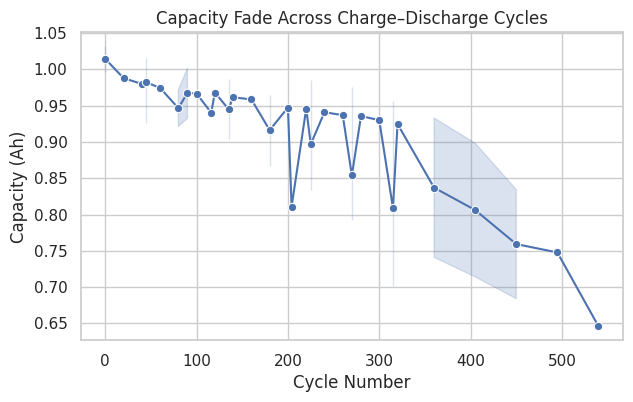

In [ ]:
#Capacity Fade Across Charge–Discharge Cycles
plt.figure(figsize=(7,4))
sns.lineplot(data=capacity_df, x="cycle_number", y="capacity_Ah", marker="o")
plt.title("Capacity Fade Across Charge–Discharge Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.show()

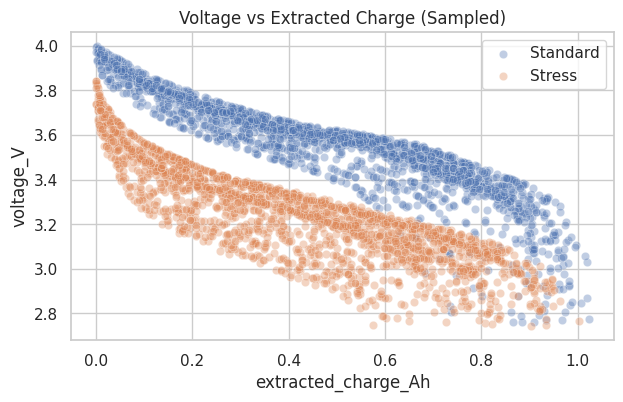

In [ ]:
# Voltage vs Extracted Charge (Sampled)
sample_std = std_df.sample(2000)
sample_stress = stress_df.sample(2000)

plt.figure(figsize=(7,4))
sns.scatterplot(data=sample_std, x="extracted_charge_Ah", y="voltage_V", alpha=0.35, label="Standard")
sns.scatterplot(data=sample_stress, x="extracted_charge_Ah", y="voltage_V", alpha=0.35, label="Stress")
plt.title("Voltage vs Extracted Charge (Sampled)")
plt.legend()
plt.show()

- Capacity steadily declines as cycle count increases, demonstrating expected degradation.
- Voltage decreases as extracted charge increases, with steeper drop under stress conditions.
- Stress tests yield lower voltages compared to standard tests due to higher load and accelerated aging.

## Data Merging

We aggregate the standard and stress test datasets because they contain high-frequency time-series measurements of voltage and extracted charge recorded many times within each charge–discharge cycle, while the capacity dataset provides one capacity value per cycle. To align these granular measurements with the cycle-level target variable and enable effective machine learning, summary statistics (mean, min, max) are computed for each battery and cycle. Aggregation transforms raw waveforms into interpretable cycle-level features that capture key degradation behavior while reducing noise and dimensionality. After aggregation, the datasets are merged on `battery_id` and `cycle_number`, producing a unified feature matrix suitable for analyzing capacity fade and building predictive models.


In [ ]:
# Aggregate standard condition dataset
std_agg = std_df.groupby(["battery_id", "cycle_number"]).agg({
    "voltage_V": ["mean", "min", "max"],
    "extracted_charge_Ah": ["mean", "max"]
}).reset_index()

std_agg.columns = [
    "battery_id", "cycle_number",
    "std_voltage_mean", "std_voltage_min", "std_voltage_max",
    "std_charge_mean", "std_charge_max"
]

# Aggregate stress condition dataset
stress_agg = stress_df.groupby(["battery_id", "cycle_number"]).agg({
    "voltage_V": ["mean", "min", "max"],
    "extracted_charge_Ah": ["mean", "max"]
}).reset_index()

stress_agg.columns = [
    "battery_id", "cycle_number",
    "stress_voltage_mean", "stress_voltage_min", "stress_voltage_max",
    "stress_charge_mean", "stress_charge_max"
]

In [ ]:
merged_df = capacity_df.merge(std_agg, on=["battery_id", "cycle_number"], how="left") \
                       .merge(stress_agg, on=["battery_id", "cycle_number"], how="left")

merged_df.head()

,battery_id,cycle_number,capacity_Ah,std_voltage_mean,std_voltage_min,std_voltage_max,std_charge_mean,std_charge_max,stress_voltage_mean,stress_voltage_min,stress_voltage_max,stress_charge_mean,stress_charge_max
0,1,0,1.026553,3.569255,2.745888,3.989748,0.513276,1.026553,3.270811,2.747810,3.822322,0.483283,0.966571
1,1,45,0.994610,3.575734,2.744262,3.998188,0.497305,0.994610,3.263805,2.749717,3.819702,0.464106,0.928216
2,1,90,0.956809,3.562115,2.745412,3.988215,0.478404,0.956809,3.241837,2.747353,3.807034,0.437027,0.874058
3,1,116,0.940173,3.553219,2.746084,3.981697,0.470087,0.940173,3.230223,2.749937,3.798943,0.420779,0.841560
4,1,135,0.922093,3.547480,2.748776,3.978592,0.461047,0.922093,3.221606,2.745812,3.794871,0.412864,0.825732


In [ ]:
print("Merged dataset shape:", merged_df.shape)
merged_df.info()
merged_df.isna().sum()

Merged dataset shape: (57, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   battery_id           57 non-null     int64  
 1   cycle_number         57 non-null     int64  
 2   capacity_Ah          57 non-null     float64
 3   std_voltage_mean     56 non-null     float64
 4   std_voltage_min      56 non-null     float64
 5   std_voltage_max      56 non-null     float64
 6   std_charge_mean      56 non-null     float64
 7   std_charge_max       56 non-null     float64
 8   stress_voltage_mean  52 non-null     float64
 9   stress_voltage_min   52 non-null     float64
 10  stress_voltage_max   52 non-null     float64
 11  stress_charge_mean   52 non-null     float64
 12  stress_charge_max    52 non-null     float64
dtypes: float64(11), int64(2)
memory usage: 5.9 KB


,0
battery_id,0
cycle_number,0
capacity_Ah,0
std_voltage_mean,1
std_voltage_min,1
std_voltage_max,1
std_charge_mean,1
std_charge_max,1
stress_voltage_mean,5
stress_voltage_min,5


In [ ]:
merged_df[merged_df.isna().any(axis=1)]

,battery_id,cycle_number,capacity_Ah,std_voltage_mean,std_voltage_min,std_voltage_max,std_charge_mean,std_charge_max,stress_voltage_mean,stress_voltage_min,stress_voltage_max,stress_charge_mean,stress_charge_max
6,1,204,0.810999,3.502754,2.749435,3.952945,0.405499,0.810999,NaN,NaN,NaN,NaN,NaN
23,2,320,0.924604,3.564638,2.747927,3.997070,0.462302,0.924604,NaN,NaN,NaN,NaN,NaN
35,3,450,0.684097,3.490685,2.746492,3.948854,0.342049,0.684097,NaN,NaN,NaN,NaN,NaN
43,4,315,0.701868,3.491614,2.748811,3.941194,0.350934,0.701868,NaN,NaN,NaN,NaN,NaN
56,5,540,0.646048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


All missing records occurred for the last cycle of each battery in the stress dataset and for the final cycle of battery 5 in the standard dataset. Since voltage and extracted-charge measurements evolve smoothly over cycles, **linear interpolation** was applied to preserve natural degradation behavior. Dropping rows would remove useful information, while replacing with mean/median would distort the degradation trend.

In [ ]:
merged_df = merged_df.sort_values(by=["battery_id", "cycle_number"])

merged_df.interpolate(method="linear", inplace=True)

In [ ]:
merged_df.isna().sum()

,0
battery_id,0
cycle_number,0
capacity_Ah,0
std_voltage_mean,0
std_voltage_min,0
std_voltage_max,0
std_charge_mean,0
std_charge_max,0
stress_voltage_mean,0
stress_voltage_min,0


## Exploratory Data Analysis after merging


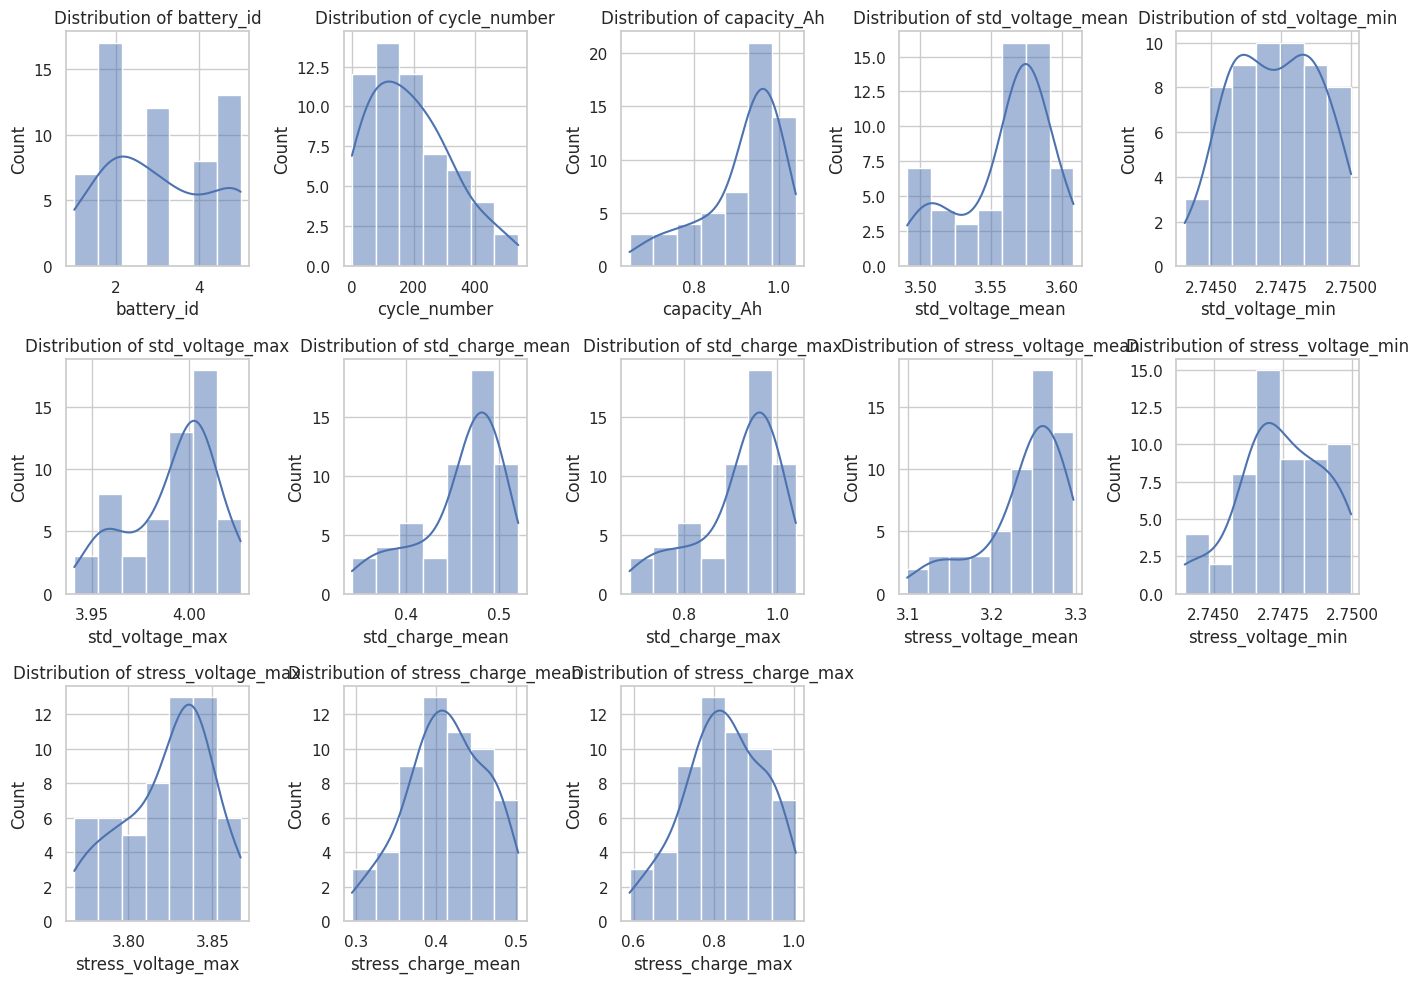

In [ ]:
# Data Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

numeric_cols = merged_df.select_dtypes(include=[float, int]).columns

plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,5,i)
    sns.histplot(merged_df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


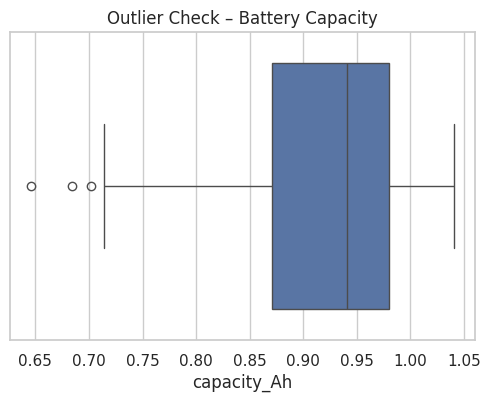

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=merged_df["capacity_Ah"])
plt.title("Outlier Check – Battery Capacity")
plt.show()

Feature distributions appear smooth with no extreme skew or heavy-tailed behavior. This suggests:
- No transformation or normalization is necessary for tree-based models.
- Outliers are minimal and consistent with natural experimental noise.

Therefore, the raw feature scales are retained.

## Visualizations

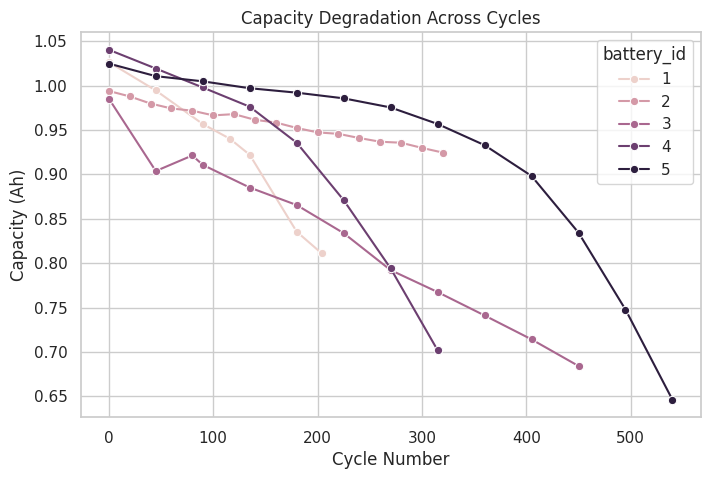

In [ ]:
# Capacity Degradation Trend Over Cycles
plt.figure(figsize=(8,5))
sns.lineplot(data=merged_df, x="cycle_number", y="capacity_Ah", hue="battery_id", marker="o")
plt.title("Capacity Degradation Across Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.show()

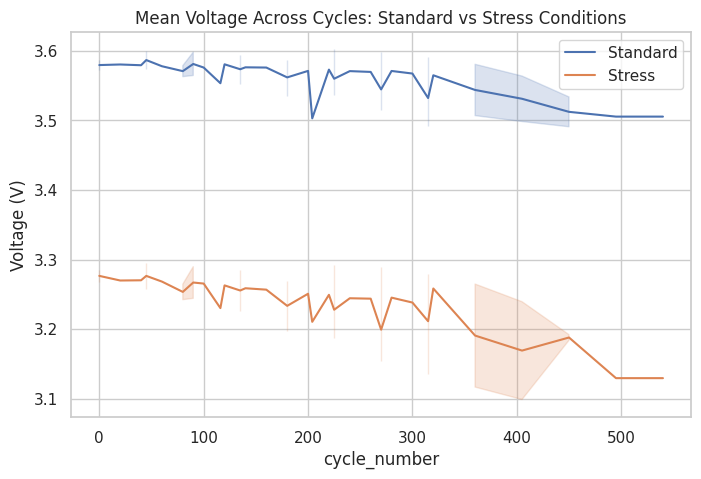

In [ ]:
# Voltage Trend Comparison (Standard vs Stress)
plt.figure(figsize=(8,5))
sns.lineplot(data=merged_df, x="cycle_number", y="std_voltage_mean", label="Standard")
sns.lineplot(data=merged_df, x="cycle_number", y="stress_voltage_mean", label="Stress")
plt.title("Mean Voltage Across Cycles: Standard vs Stress Conditions")
plt.ylabel("Voltage (V)")
plt.show()

Stress tests show low voltage due to the kind of testing that happens as compared to standard testing but i both cases as the number of cycles increase the voltage decreases

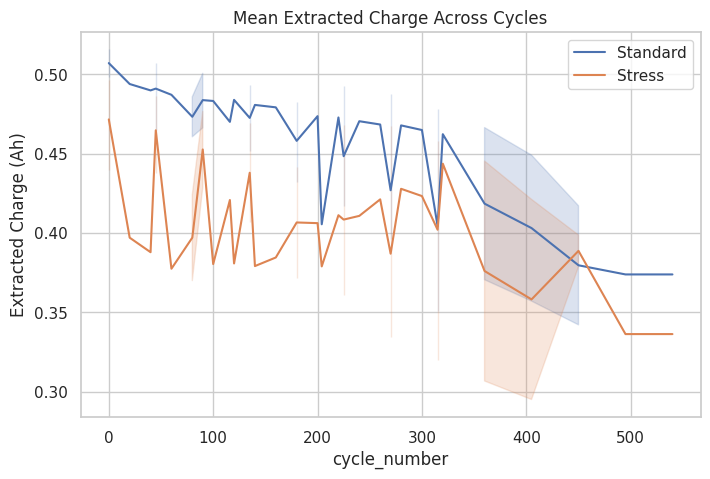

In [ ]:
# Extracted Charge Comparison
plt.figure(figsize=(8,5))
sns.lineplot(data=merged_df, x="cycle_number", y="std_charge_mean", label="Standard")
sns.lineplot(data=merged_df, x="cycle_number", y="stress_charge_mean", label="Stress")
plt.title("Mean Extracted Charge Across Cycles")
plt.ylabel("Extracted Charge (Ah)")
plt.show()

- Capacity degradation curves confirm expected aging behavior across all batteries.
- Under stress, batteries show lower voltage and extracted-charge levels, indicating accelerated capacity loss.
- These differences become stronger as cycle count increases.

### Correlation


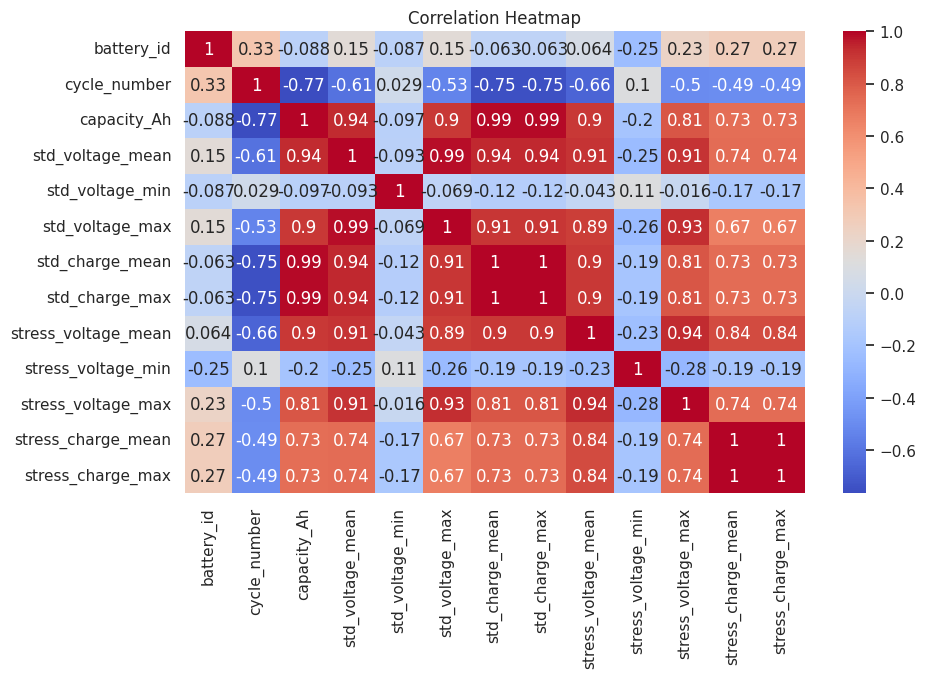

In [ ]:
plt.figure(figsize=(10,6))
corr = merged_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows strong positive correlations between capacity and voltage- and charge-related features under both standard and stress conditions. As expected, `capacity_Ah` strongly correlates with `std_voltage_mean`, `std_voltage_max`, `std_charge_mean`, and their stress equivalents, indicating that voltage and usable charge decline together as the battery ages. Stress-condition voltage and charge features are especially highly correlated with capacity, suggesting that stress testing reveals degradation effects more clearly. Differences between standard and stress performance (`delta` features) are therefore likely to be strong predictors in modeling. Additionally, `cycle_number` shows a strong negative correlation with capacity (–0.77), reflecting natural battery wear over time. Overall, the correlation structure confirms that voltage and extracted charge behavior offer meaningful signal for predicting remaining battery capacity.

# Task 2: Feature Engineering

To design meaningful predictive features for capacity estimation, we first evaluate the multicollinearity among the existing voltage and charge features. Since these measurements describe similar electrochemical behavior, they often move together during battery aging. High multicollinearity can negatively impact linear models by producing unstable coefficients and reducing interpretability, even though tree-based models remain robust.

We computed the Variance Inflation Factor (VIF) for all numerical sensor features. VIF values substantially greater than 10 indicate severe multicollinearity.


In [ ]:
# Multicollinearity Check using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select numeric feature columns (exclude target and identifiers)
features = merged_df[[
    "cycle_number",
    "std_voltage_mean", "std_voltage_min", "std_voltage_max",
    "std_charge_mean", "std_charge_max",
    "stress_voltage_mean", "stress_voltage_min", "stress_voltage_max",
    "stress_charge_mean", "stress_charge_max"
]]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]

vif_data

,feature,VIF
0,cycle_number,1.374559e+01
1,std_voltage_mean,2.021543e+06
2,std_voltage_min,2.585060e+06
3,std_voltage_max,6.725521e+06
4,std_charge_mean,7.928873e+12
5,std_charge_max,7.928873e+12
6,stress_voltage_mean,1.916492e+05
7,stress_voltage_min,2.122680e+06
8,stress_voltage_max,1.221666e+06
9,stress_charge_mean,2.276270e+12


The VIF results show extremely high multicollinearity among voltage and

1.   List item
2.   List item

extracted charge measurements under both standard and stress conditions, with VIF values reaching as high as 10⁶–10¹². This is expected since these variables represent the same discharge curve behavior and naturally change together as the battery ages.

To reduce redundancy and retain interpretable signals for modeling, we selected representative features and created derived *delta features* that quantify performance differences between standard and stress conditions—key indicators of battery degradation.


In [ ]:
# Create delta features representing degradation under stress
merged_df["voltage_delta_mean"] = merged_df["std_voltage_mean"] - merged_df["stress_voltage_mean"]
merged_df["charge_delta_mean"] = merged_df["std_charge_mean"] - merged_df["stress_charge_mean"]

# Normalized capacity (percentage of initial battery capacity)
initial_cap = merged_df.groupby("battery_id")["capacity_Ah"].transform("max")
merged_df["capacity_pct"] = merged_df["capacity_Ah"] / initial_cap

final_columns = [
    "cycle_number",
    "std_voltage_mean", "std_charge_mean",
    "stress_voltage_mean", "stress_charge_mean",
    "voltage_delta_mean", "charge_delta_mean", "capacity_Ah"
]

merged_df = merged_df[final_columns]
merged_df.head()

,cycle_number,std_voltage_mean,std_charge_mean,stress_voltage_mean,stress_charge_mean,voltage_delta_mean,charge_delta_mean,capacity_Ah
0,0,3.569255,0.513276,3.270811,0.483283,0.298443,0.029993,1.026553
1,45,3.575734,0.497305,3.263805,0.464106,0.311929,0.033200,0.994610
2,90,3.562115,0.478404,3.241837,0.437027,0.320279,0.041377,0.956809
3,116,3.553219,0.470087,3.230223,0.420779,0.322996,0.049308,0.940173
4,135,3.547480,0.461047,3.221606,0.412864,0.325875,0.048182,0.922093


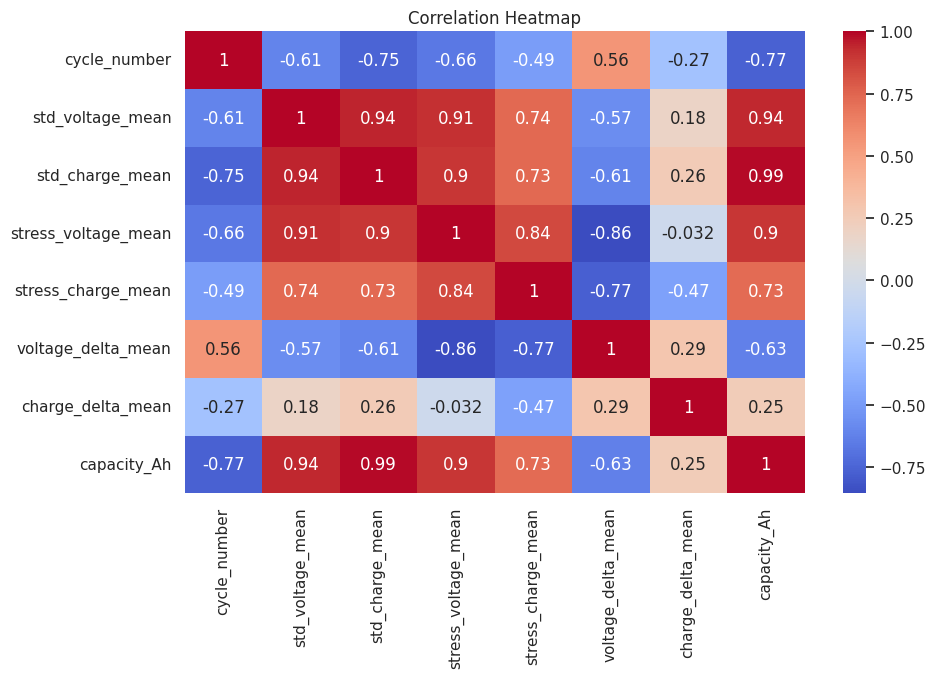

In [ ]:
plt.figure(figsize=(10,6))
corr = merged_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The updated correlation heatmap shows expected strong correlations between voltage and charge measurements, as these features represent the same underlying discharge behavior and naturally change together as the battery ages. While some predictor pairs remain highly correlated (correlations ~0.9), this is acceptable for tree-based models such as Random Forest and XGBoost, which are robust to multicollinearity. Linear regression models, however, can be affected by unstable coefficients when predictors are strongly collinear, so a reduced feature set and engineered delta features were retained to improve interpretability.

We chose to remove `voltage_mean` and `charge_mean` due to strong multicollinearity, domain relevance and to avoid data leakage

## Task 3: Modeling


Our goal is to predict the continuous variable battery capacity (Ah) as it declines across charge–discharge cycles. Therefore, this is a regression problem. Since the dataset is relatively small (only a few hundred aggregated observations after grouping) and not highly nonlinear, we begin with Linear regression.

Linear Regression is our baseline model bacause it is interpretable and  identifies linear relationships.
Then, Random Forest Regressor	as it is capable of handling non-linear interactions, robust to collinearity and good for small/medium tabular data
Finally, XGBoost model to capture complex aging patterns

We evaluate performance using RMSE (Root Mean Squared Error) and R² (Coefficient of Determination), standard metrics for regression-based continuous prediction.

In [ ]:
# Final modeling dataset (reduced and engineered feature set)
feature_cols = [
    "cycle_number",
    # "std_voltage_mean", "stress_voltage_mean",
    "voltage_delta_mean", "charge_delta_mean"
]

target_col = "capacity_Ah"
X = merged_df[feature_cols]
y = merged_df[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

# Evaluate Models
def metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return rmse, r2

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_rmse, lr_r2 = metrics(y_test, lr_pred)
print(f"Linear Regression → RMSE: {lr_rmse:.4f}, R²: {lr_r2:.4f}")


Linear Regression → RMSE: 0.0395, R²: 0.8517


In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_rmse, rf_r2 = metrics(y_test, rf_pred)
print(f"Random Forest     → RMSE: {rf_rmse:.4f}, R²: {rf_r2:.4f}")

Random Forest     → RMSE: 0.0230, R²: 0.9495


In [ ]:
# XGBoost Model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_rmse, xgb_r2 = metrics(y_test, xgb_pred)
print(f"XGBoost           → RMSE: {xgb_rmse:.4f}, R²: {xgb_r2:.4f}")

XGBoost           → RMSE: 0.0306, R²: 0.9107


In [ ]:
print("Model Performance Comparison:\n")
print(f"Linear Regression → RMSE: {lr_rmse:.4f}, R²: {lr_r2:.4f}")
print(f"Random Forest     → RMSE: {rf_rmse:.4f}, R²: {rf_r2:.4f}")
print(f"XGBoost           → RMSE: {xgb_rmse:.4f}, R²: {xgb_r2:.4f}")

Model Performance Comparison:

Linear Regression → RMSE: 0.0395, R²: 0.8517
Random Forest     → RMSE: 0.0230, R²: 0.9495
XGBoost           → RMSE: 0.0306, R²: 0.9107


## Task 4: Model Interpretation and Insights

Random Forest achieved the best performance (RMSE = 0.0230, R² = 0.9495), outperforming Linear Regression and XGBoost. This indicates that lithium-polymer battery degradation follows a nonlinear pattern with cycle progression.

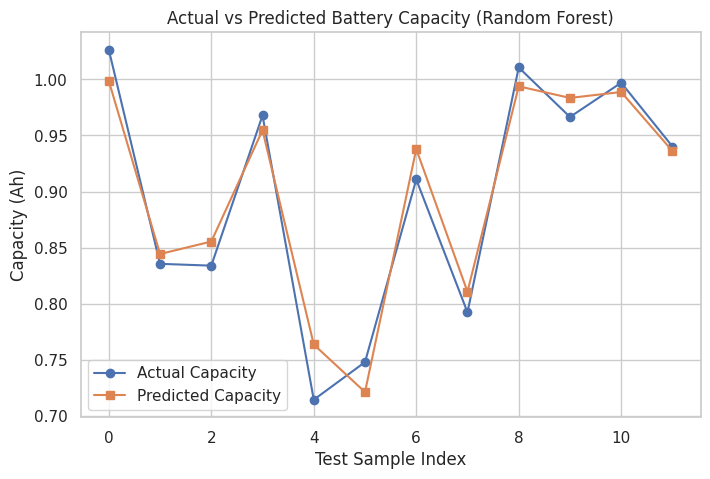

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create comparison dataframe
rf_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
}).sort_index()

plt.figure(figsize=(8,5))
plt.plot(rf_results["Actual"].values, label="Actual Capacity", marker="o")
plt.plot(rf_results["Predicted"].values, label="Predicted Capacity", marker="s")
plt.title("Actual vs Predicted Battery Capacity (Random Forest)")
plt.xlabel("Test Sample Index")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

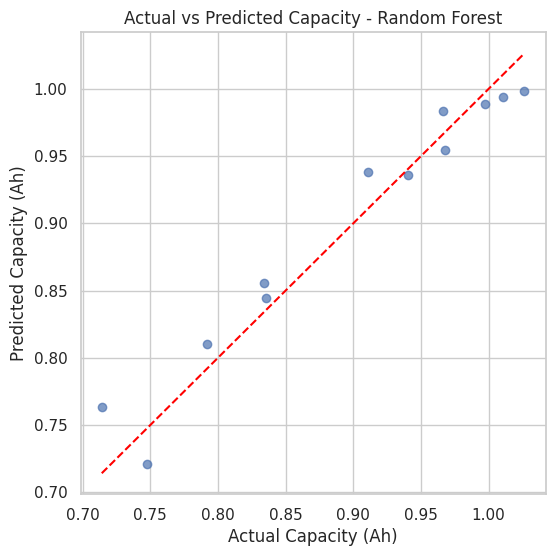

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(rf_results["Actual"], rf_results["Predicted"], alpha=0.7)
plt.plot([rf_results["Actual"].min(), rf_results["Actual"].max()],
         [rf_results["Actual"].min(), rf_results["Actual"].max()],
         color="red", linestyle="--")  # reference line
plt.title("Actual vs Predicted Capacity - Random Forest")
plt.xlabel("Actual Capacity (Ah)")
plt.ylabel("Predicted Capacity (Ah)")
plt.grid(True)
plt.show()

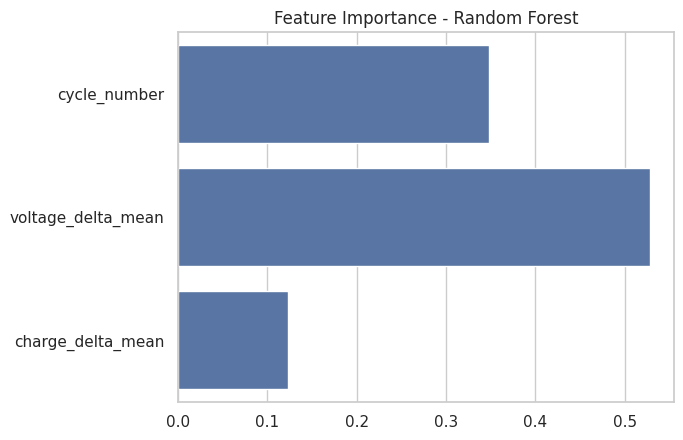

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_importances = rf.feature_importances_
sns.barplot(x=rf_importances, y=feature_cols)
plt.title("Feature Importance - Random Forest")
plt.show()

The Random Forest feature importance plot shows that **`voltage_delta_mean` is the most influential feature** in predicting lithium-polymer battery capacity. This metric captures the difference between mean voltage under standard and stress testing conditions, and a larger delta indicates that the battery is losing voltage more rapidly under load — a strong electrochemical sign of internal resistance increase and aging. **`cycle_number`** is the second most important feature, confirming the expected trend that batteries degrade gradually with repeated usage. **`charge_delta_mean`** has lower importance, suggesting changes in extracted charge between testing conditions are weaker indicators compared to voltage behavior.

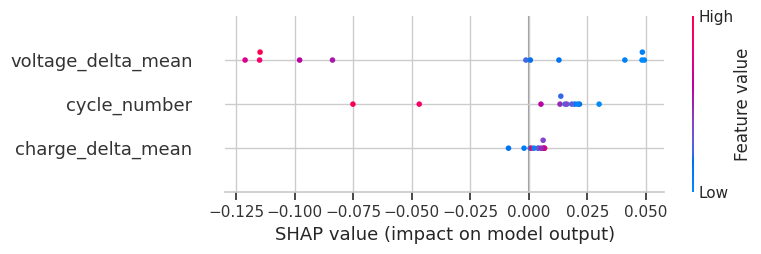

In [ ]:
import shap

# Initialize SHAP
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="dot")

The SHAP summary plot reinforces these insights by showing:
- **High values of `voltage_delta_mean` push predictions strongly negative**, meaning a large voltage gap corresponds to lower predicted capacity.
- **Higher cycle numbers also push capacity lower**, though with less magnitude than voltage degradation effects.
- **Low values of `voltage_delta_mean` and lower cycle counts push predictions upward**, representing healthier batteries.

Together, the feature importance and SHAP visualizations demonstrate that **voltage stability under varying load is the most critical predictor of battery capacity fade**, stronger than simply counting charge–discharge cycles. This aligns closely with real-world electrochemical aging behavior, where increased internal resistance weakens voltage performance long before charge capacity visibly declines.

These insights support data-driven maintenance decisions such as:
- Monitoring voltage drop under stress to detect early degradation,
- Predicting useful life more accurately than cycle-count-based heuristics,
- Improving manufacturing and material optimization strategies.